In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from pandas.core.common import random_state

warnings.filterwarnings("ignore")

from nn.activation_functions import sigmoid, sigmoid_deriv
from nn.network import SimpleNetwork
from nn.wrappers import  MinMaxScaler
from nn.metrics import mse

In [2]:
def lab3(train_path, test_path, hidden_layers_sizes, epochs, learning_rate, batch_size, random_state = 42, init_method = 'uniform', mode = "momentum", momentum = 0.9):

    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)

    X_train = train[['x']].values
    X_test = test[['x']].values
    y_train = train[['y']].values
    y_test = test[['y']].values


    x_scaler = MinMaxScaler()
    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_scaler = MinMaxScaler()
    y_train_scaled = y_scaler.fit_transform(y_train)

    model = SimpleNetwork(
        input_size=1,
        output_size=1,
        hidden_layers_sizes=hidden_layers_sizes,
        activation_func=sigmoid,
        activation_deriv=sigmoid_deriv,
        init_method=init_method,
        random_state= random_state
    )

    history = model.fit_with_history(X_train_scaled,
                                     y_train_scaled,
                                     epochs=epochs,
                                     learning_rate=learning_rate,
                                     batch_size=batch_size,
                                     mode = mode,
                                     momentum = momentum)

    y_train_pred = y_scaler.inverse_transform(model.predict(X_train_scaled))
    y_test_pred = y_scaler.inverse_transform(model.predict(X_test_scaled))

    print(f'MSE na nieznormalizowanym zbiorze treningowym : {mse(y_train, y_train_pred):.4f}')
    print(f'MSE na nieznormalizowanym zbiorze testowym    : {mse(y_test, y_test_pred):.4f}')


    #wykresyt
    num_layers = len(model.layers)
    fig = plt.figure(figsize=(18, 10))


    ax_fit_train = fig.add_subplot(2, 3, 1)
    ax_fit_test = fig.add_subplot(2, 3, 2)
    ax_loss = fig.add_subplot(2, 3, 3)

    # Wykres 1: Dopasowanie na zbiorze treningowym
    ax_fit_train.scatter(X_train, y_train, label='Oryginalne dane', color='blue', s=10)
    ax_fit_train.scatter(X_train, y_train_pred, label='Predykcja', color='red', s=10)
    ax_fit_train.set_title("Dopasowanie (Train)")
    ax_fit_train.set_xlabel("x")
    ax_fit_train.set_ylabel("y")
    ax_fit_train.legend()
    ax_fit_train.grid(True, linestyle='--', alpha=0.7)

    # Wykres 2: Dopasowanie na zbiorze testowym
    ax_fit_test.scatter(X_test, y_test, label='Oryginalne dane', color='blue', s=10)
    ax_fit_test.scatter(X_test, y_test_pred, label='Predykcja', color='orange', s=10)
    ax_fit_test.set_title("Dopasowanie (Test)")
    ax_fit_test.set_xlabel("x")
    ax_fit_test.set_ylabel("y")
    ax_fit_test.legend()
    ax_fit_test.grid(True, linestyle='--', alpha=0.7)

    # Wykres 3: Krzywa uczenia
    ax_loss.plot(history['loss'], color='red', linewidth=2)
    ax_loss.set_title("Krzywa uczenia na Train (MSE)")
    ax_loss.set_xlabel("Epoka")
    ax_loss.set_ylabel("Błąd MSE")
    ax_loss.grid(True, linestyle='--', alpha=0.7)

    # Wagi w kolejnych epokach
    for layer_idx in range(num_layers):
        #podział dolnego rzędu na podstawie ilości warstw
        ax_w = fig.add_subplot(2, num_layers, num_layers + layer_idx + 1)
        layer_weights = np.array(history['weights'][layer_idx])

        # inie dla każdego połączenia wag
        for input_idx in range(layer_weights.shape[1]):
            for neuron_idx in range(layer_weights.shape[2]):
                ax_w.plot(layer_weights[:, input_idx, neuron_idx],
                          label=f'w({input_idx}->{neuron_idx})' if layer_weights.shape[1] * layer_weights.shape[2] <= 10 else "")

        title = f"Wagi - Warstwa {layer_idx + 1}"
        if layer_idx == num_layers - 1:
            title += " (Wyjściowa)"
        else:
            title += " (Ukryta)"

        ax_w.set_title(title)
        ax_w.set_xlabel("Epoka")
        ax_w.grid(True, linestyle='--', alpha=0.7)

        #jeśli wag nie jest za dużo
        if layer_weights.shape[1] * layer_weights.shape[2] <= 10:
            ax_w.legend()

    plt.tight_layout()
    plt.show()

    return mse(y_test, y_test_pred)

MSE na nieznormalizowanym zbiorze treningowym : 7543.2970
MSE na nieznormalizowanym zbiorze testowym    : 5639.8614


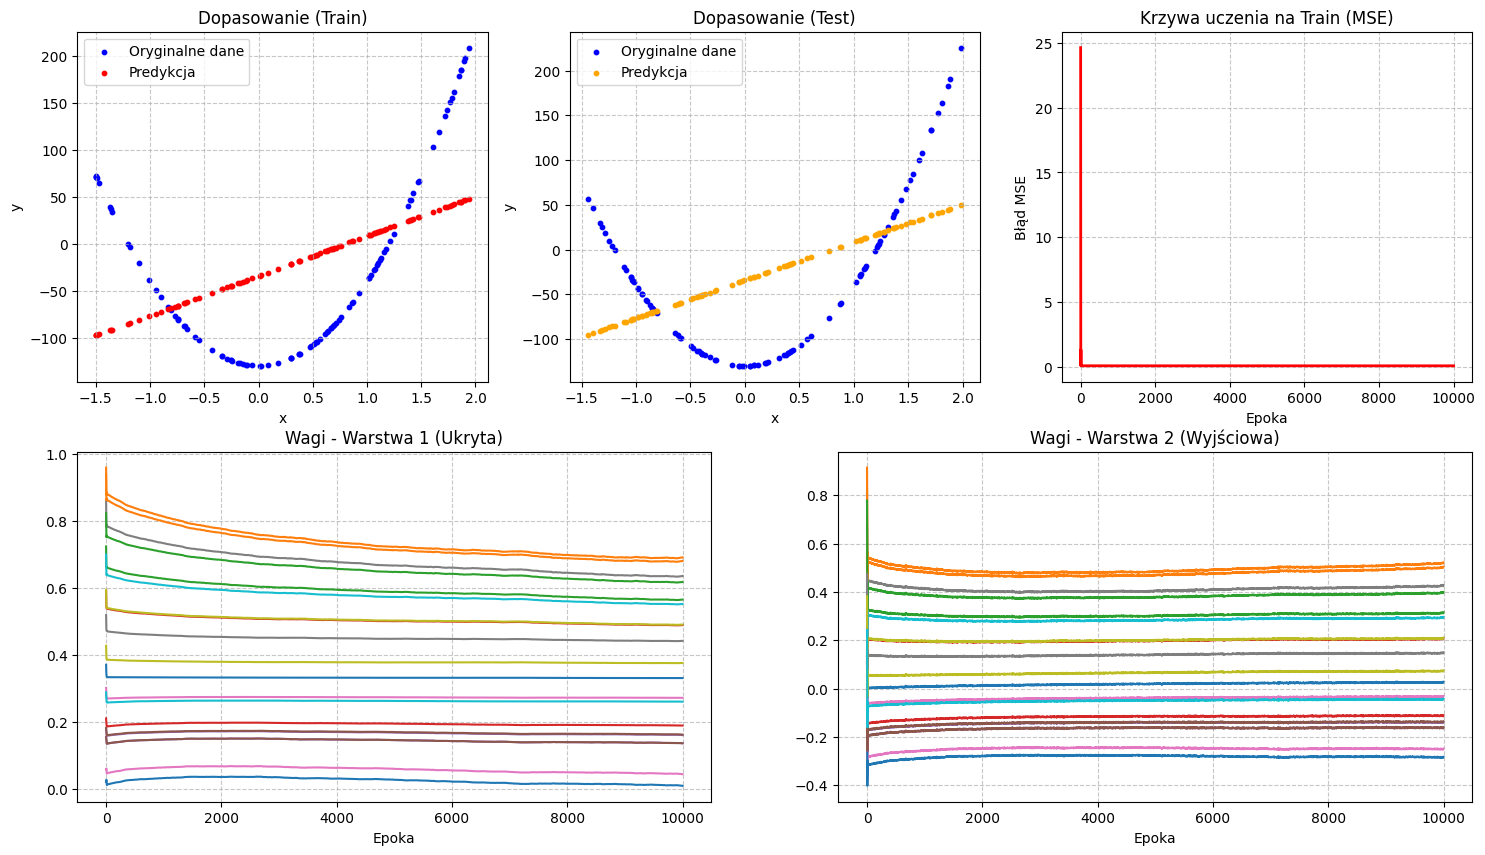

np.float64(5639.861376066649)

In [4]:
lab3(train_path='../../datasets/regression/square-simple-training.csv',
     test_path='../../datasets/regression/square-simple-test.csv',
     hidden_layers_sizes = [20],
     epochs = 10000,
     learning_rate = 0.001,
     batch_size = 32,
     )

MSE na nieznormalizowanym zbiorze treningowym : 55.9455
MSE na nieznormalizowanym zbiorze testowym    : 48.3778


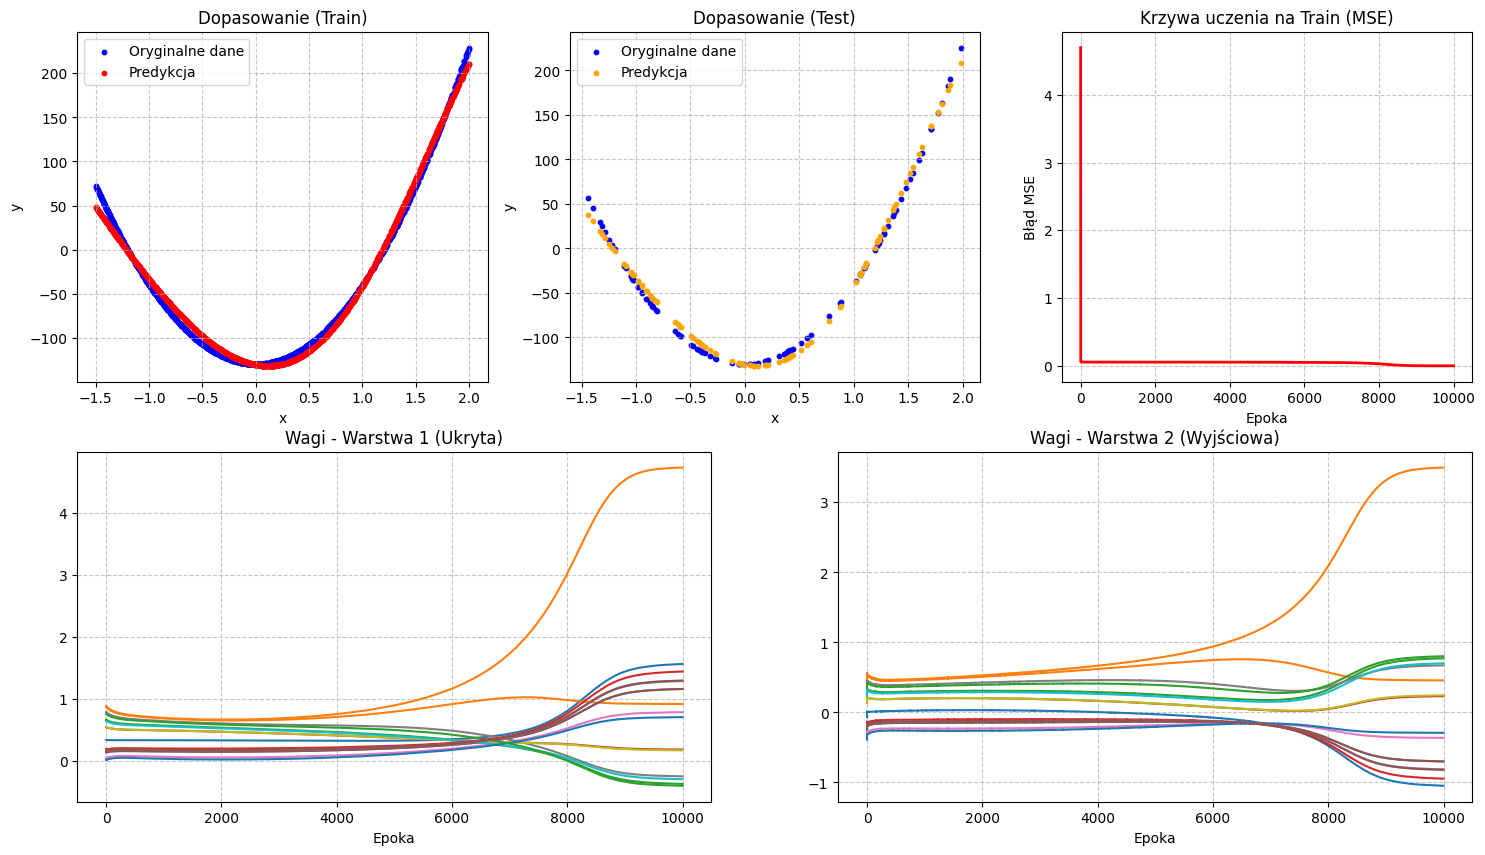

np.float64(48.37779916820469)

In [4]:
lab3(train_path='../../datasets/regression/square-large-training.csv',
     test_path='../../datasets/regression/square-simple-test.csv',
     hidden_layers_sizes = [16],
     epochs = 10000,
     learning_rate = 0.001,
     batch_size = 32,
     )

MSE na nieznormalizowanym zbiorze treningowym : 55.9455
MSE na nieznormalizowanym zbiorze testowym    : 434.8301


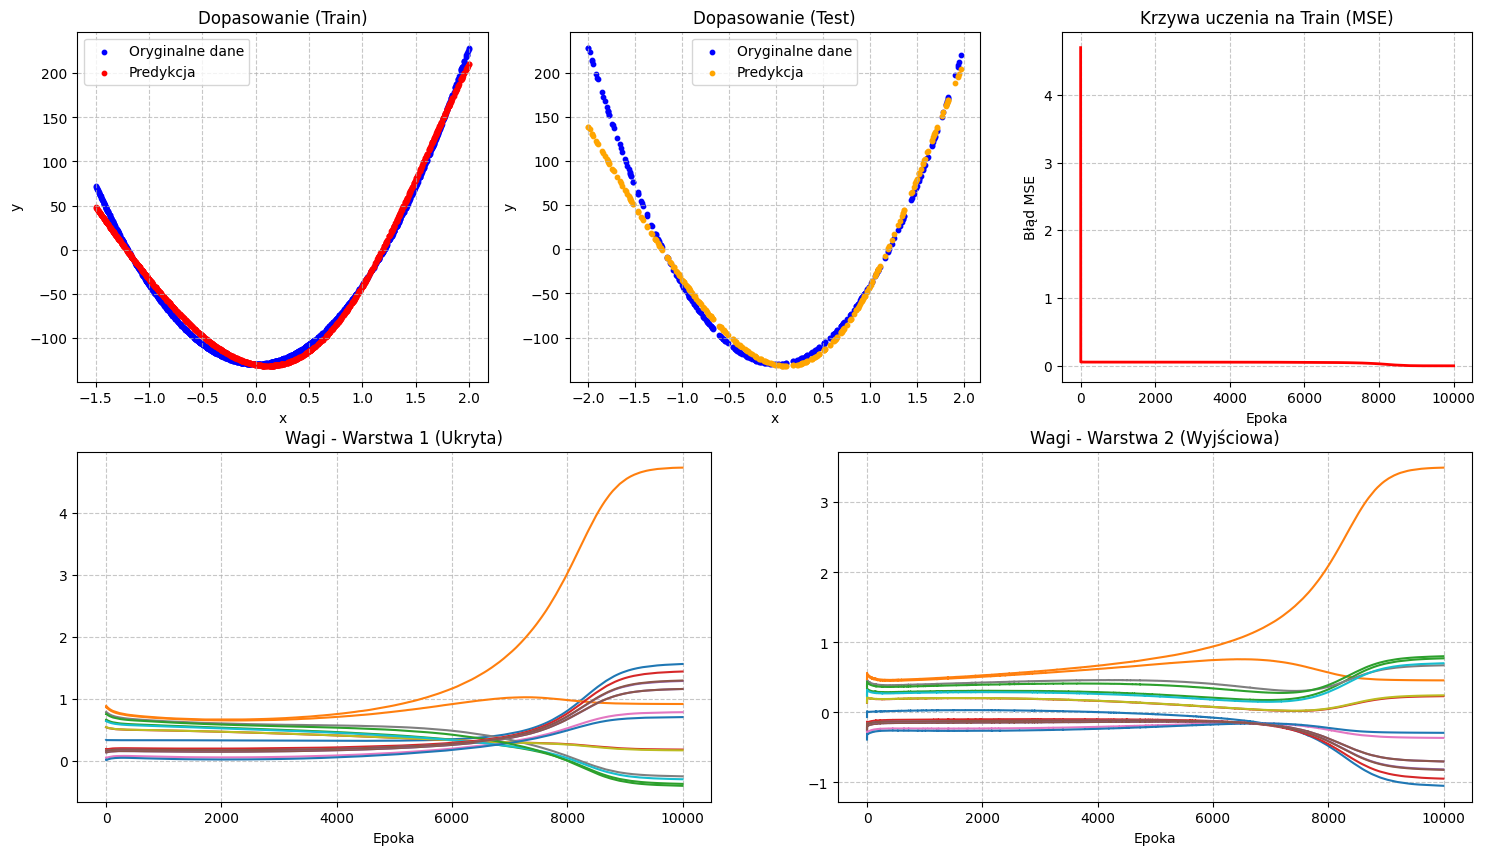

np.float64(434.8300570457926)

In [5]:
lab3(train_path='../../datasets/regression/square-large-training.csv',
     test_path='../../datasets/regression/square-large-test.csv',
     hidden_layers_sizes = [16],
     epochs = 10000,
     learning_rate = 0.001,
     batch_size = 32,
     )

MSE na nieznormalizowanym zbiorze treningowym : 7950.3004
MSE na nieznormalizowanym zbiorze testowym    : 9386.6119


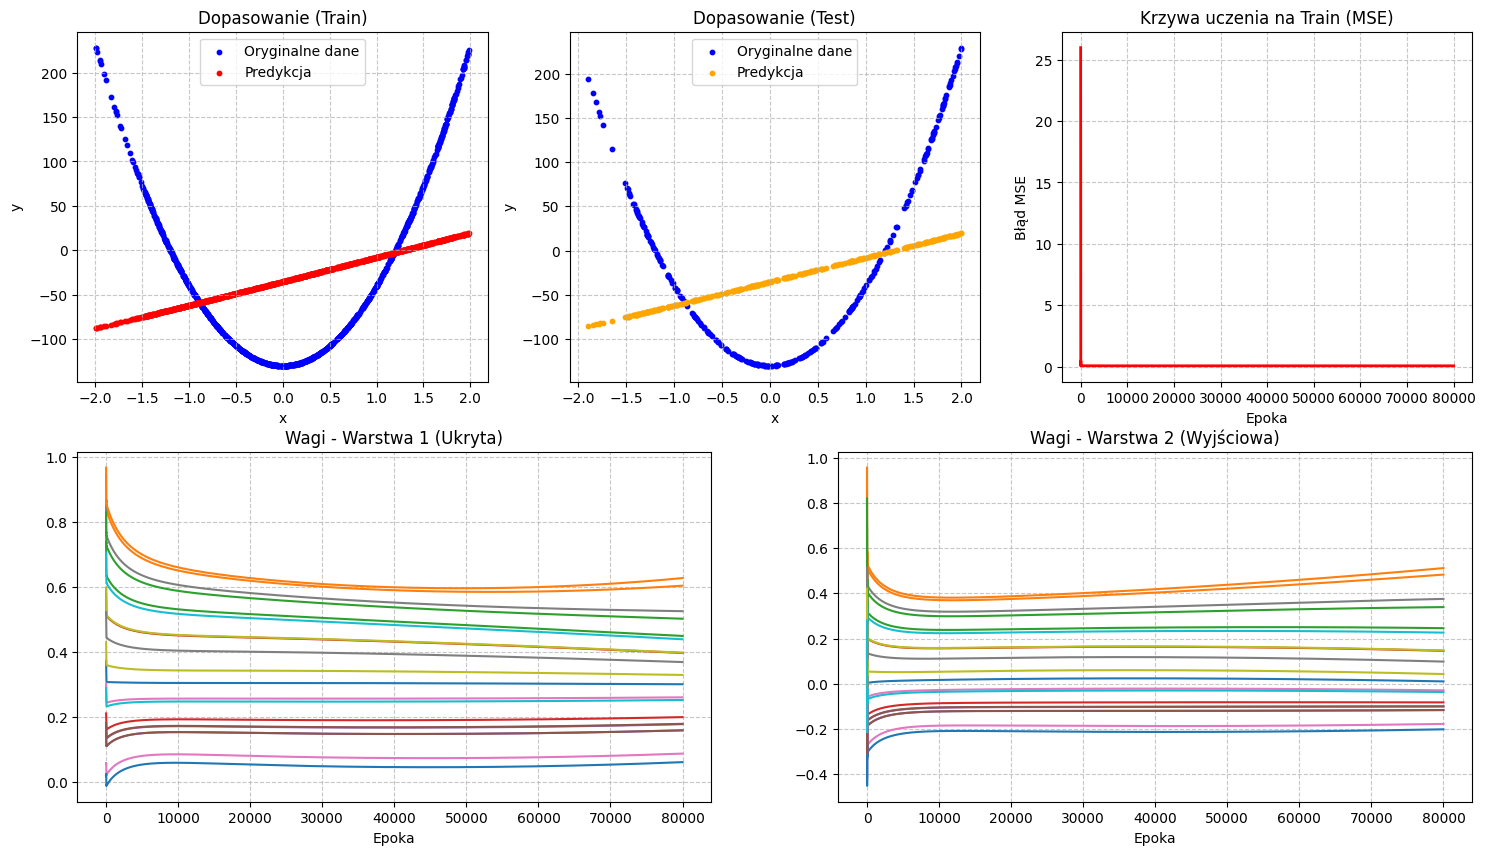

np.float64(9386.611912859335)

In [6]:
lab3(train_path='../../datasets/regression/my-square-large-training.csv',
     test_path='../../datasets/regression/my-square-large-test.csv',
     hidden_layers_sizes = [20],
     epochs = 80000,
     learning_rate = 0.002,
     batch_size = None
     )

MSE na nieznormalizowanym zbiorze treningowym : 479.9009
MSE na nieznormalizowanym zbiorze testowym    : 485.0289


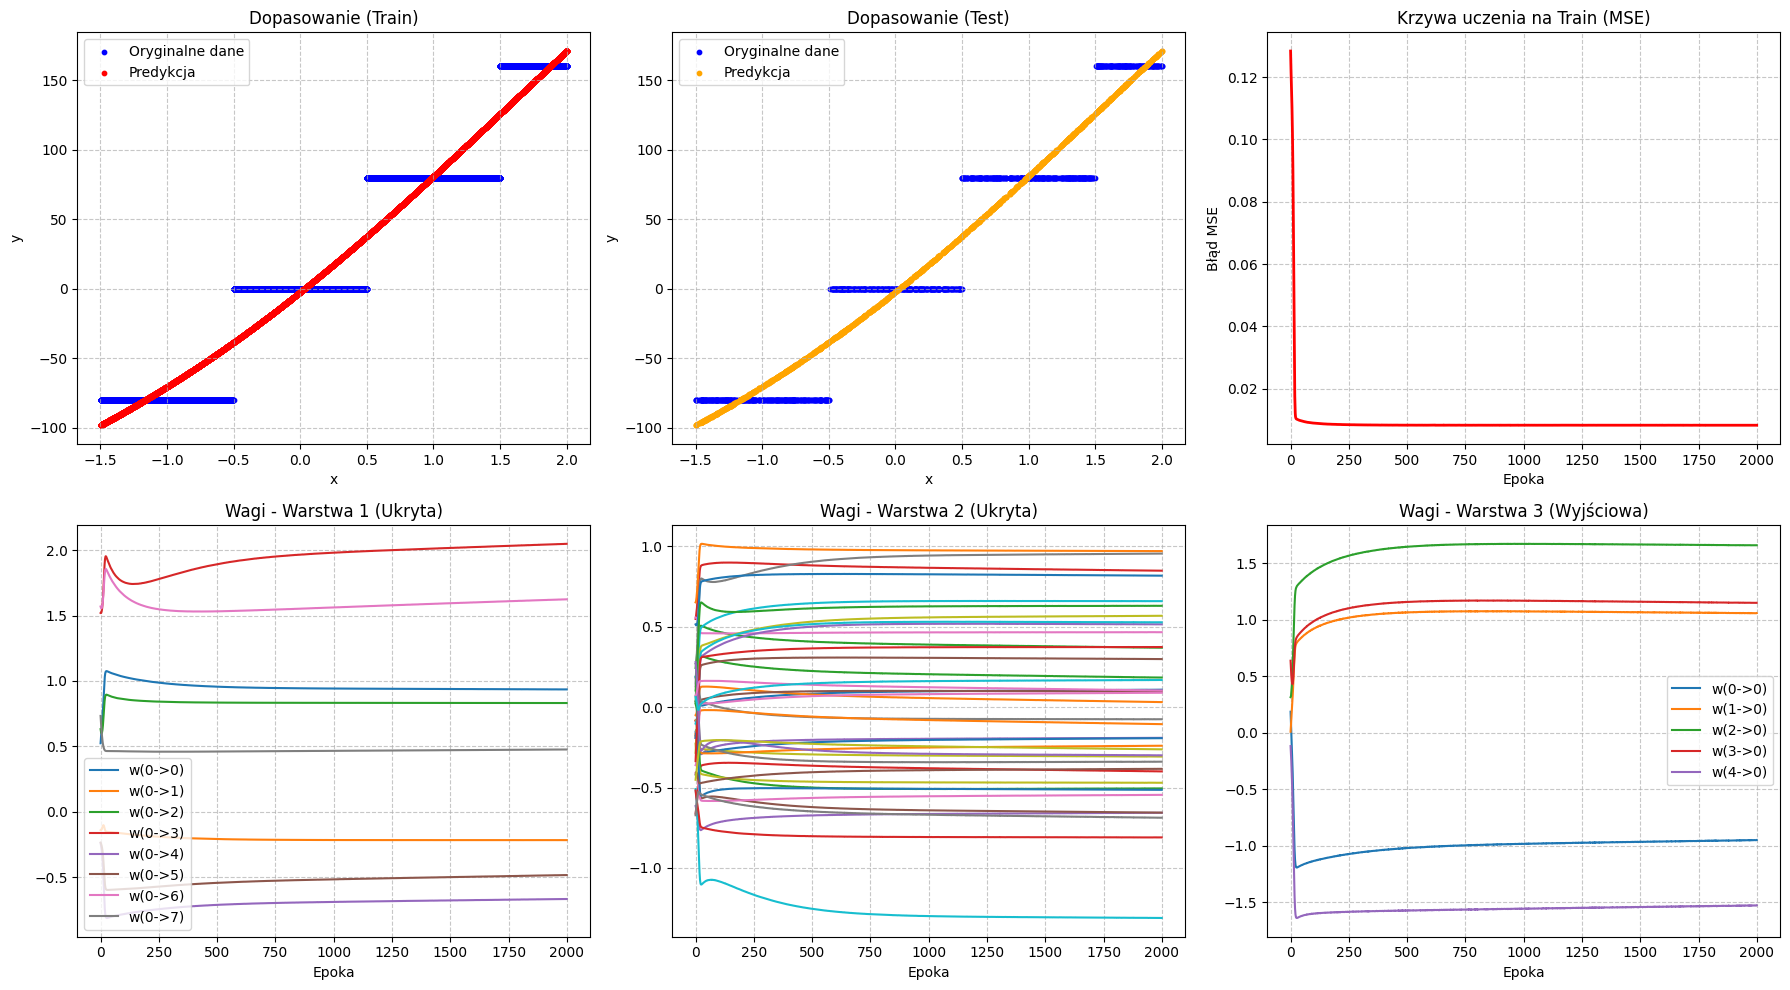

np.float64(485.02891322424927)

In [7]:
lab3(train_path='../../datasets/regression/steps-large-training.csv',
     test_path='../../datasets/regression/steps-large-test.csv',
     hidden_layers_sizes = [8,5],
     epochs = 2000,
     learning_rate = 0.002,
     batch_size = 32,
     init_method = 'xavier'
     ) #4,56




MSE na nieznormalizowanym zbiorze treningowym : 2625.0863
MSE na nieznormalizowanym zbiorze testowym    : 2579.2107


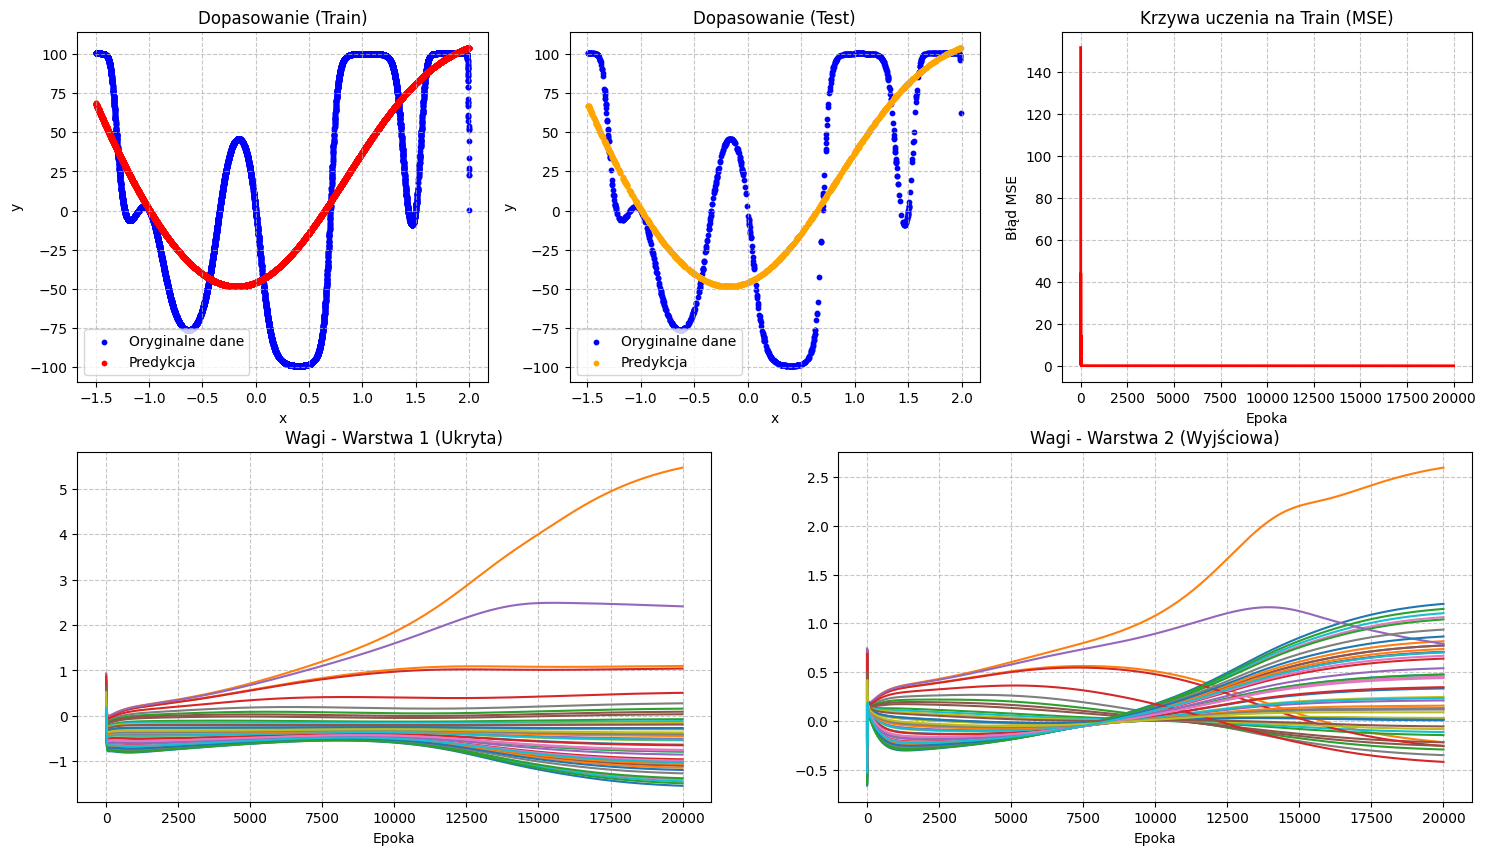

np.float64(2579.21072900962)

In [8]:
lab3(train_path='../../datasets/regression/multimodal-large-training.csv',
     test_path='../../datasets/regression/multimodal-large-test.csv',
     hidden_layers_sizes = [50],
     epochs = 20000,
     learning_rate = 0.015,
     batch_size = None,
     )

## Wyniki dla rmsprop

In [11]:
def lab3_rmsprop(train_path, test_path, hidden_layers_sizes, epochs, learning_rate, batch_size, random_state = 42, init_method = 'uniform', mode = "rmsprop", decay_rate = 0.9):

    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)

    X_train = train[['x']].values
    X_test = test[['x']].values
    y_train = train[['y']].values
    y_test = test[['y']].values


    x_scaler = MinMaxScaler()
    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_scaler = MinMaxScaler()
    y_train_scaled = y_scaler.fit_transform(y_train)

    model = SimpleNetwork(
        input_size=1,
        output_size=1,
        hidden_layers_sizes=hidden_layers_sizes,
        activation_func=sigmoid,
        activation_deriv=sigmoid_deriv,
        init_method=init_method,
        random_state= random_state
    )

    history = model.fit_with_history(X_train_scaled,
                                     y_train_scaled,
                                     epochs=epochs,
                                     learning_rate=learning_rate,
                                     batch_size=batch_size,
                                     mode = mode,
                                     decay_rate=decay_rate)

    y_train_pred = y_scaler.inverse_transform(model.predict(X_train_scaled))
    y_test_pred = y_scaler.inverse_transform(model.predict(X_test_scaled))

    print(f'MSE na nieznormalizowanym zbiorze treningowym : {mse(y_train, y_train_pred):.4f}')
    print(f'MSE na nieznormalizowanym zbiorze testowym    : {mse(y_test, y_test_pred):.4f}')


    #wykresyt
    num_layers = len(model.layers)
    fig = plt.figure(figsize=(18, 10))


    ax_fit_train = fig.add_subplot(2, 3, 1)
    ax_fit_test = fig.add_subplot(2, 3, 2)
    ax_loss = fig.add_subplot(2, 3, 3)

    # Wykres 1: Dopasowanie na zbiorze treningowym
    ax_fit_train.scatter(X_train, y_train, label='Oryginalne dane', color='blue', s=10)
    ax_fit_train.scatter(X_train, y_train_pred, label='Predykcja', color='red', s=10)
    ax_fit_train.set_title("Dopasowanie (Train)")
    ax_fit_train.set_xlabel("x")
    ax_fit_train.set_ylabel("y")
    ax_fit_train.legend()
    ax_fit_train.grid(True, linestyle='--', alpha=0.7)

    # Wykres 2: Dopasowanie na zbiorze testowym
    ax_fit_test.scatter(X_test, y_test, label='Oryginalne dane', color='blue', s=10)
    ax_fit_test.scatter(X_test, y_test_pred, label='Predykcja', color='orange', s=10)
    ax_fit_test.set_title("Dopasowanie (Test)")
    ax_fit_test.set_xlabel("x")
    ax_fit_test.set_ylabel("y")
    ax_fit_test.legend()
    ax_fit_test.grid(True, linestyle='--', alpha=0.7)

    # Wykres 3: Krzywa uczenia
    ax_loss.plot(history['loss'], color='red', linewidth=2)
    ax_loss.set_title("Krzywa uczenia na Train (MSE)")
    ax_loss.set_xlabel("Epoka")
    ax_loss.set_ylabel("Błąd MSE")
    ax_loss.grid(True, linestyle='--', alpha=0.7)

    # Wagi w kolejnych epokach
    for layer_idx in range(num_layers):
        #podział dolnego rzędu na podstawie ilości warstw
        ax_w = fig.add_subplot(2, num_layers, num_layers + layer_idx + 1)
        layer_weights = np.array(history['weights'][layer_idx])

        # inie dla każdego połączenia wag
        for input_idx in range(layer_weights.shape[1]):
            for neuron_idx in range(layer_weights.shape[2]):
                ax_w.plot(layer_weights[:, input_idx, neuron_idx],
                          label=f'w({input_idx}->{neuron_idx})' if layer_weights.shape[1] * layer_weights.shape[2] <= 10 else "")

        title = f"Wagi - Warstwa {layer_idx + 1}"
        if layer_idx == num_layers - 1:
            title += " (Wyjściowa)"
        else:
            title += " (Ukryta)"

        ax_w.set_title(title)
        ax_w.set_xlabel("Epoka")
        ax_w.grid(True, linestyle='--', alpha=0.7)

        #jeśli wag nie jest za dużo
        if layer_weights.shape[1] * layer_weights.shape[2] <= 10:
            ax_w.legend()

    plt.tight_layout()
    plt.show()

    return mse(y_test, y_test_pred)

MSE na nieznormalizowanym zbiorze treningowym : 19.8939
MSE na nieznormalizowanym zbiorze testowym    : 24.6160


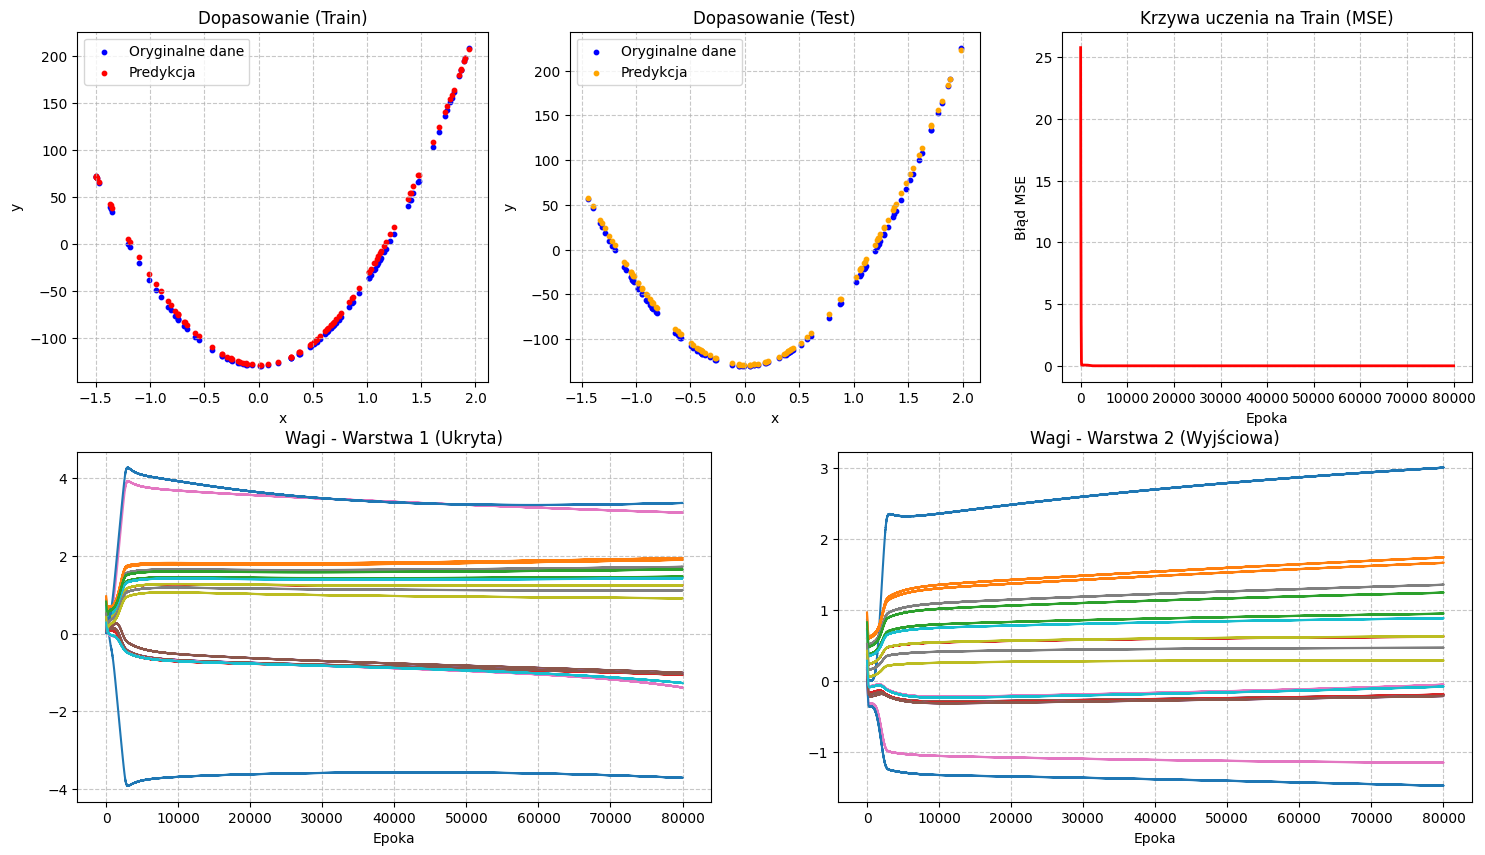

np.float64(24.61602219235557)

In [12]:
lab3_rmsprop(train_path='../../datasets/regression/square-simple-training.csv',
     test_path='../../datasets/regression/square-simple-test.csv',
     hidden_layers_sizes = [20],
     epochs = 80000,
     learning_rate = 0.002,
     batch_size = None,
     decay_rate = 0.9
     )

MSE na nieznormalizowanym zbiorze treningowym : 24.3730
MSE na nieznormalizowanym zbiorze testowym    : 27.4284


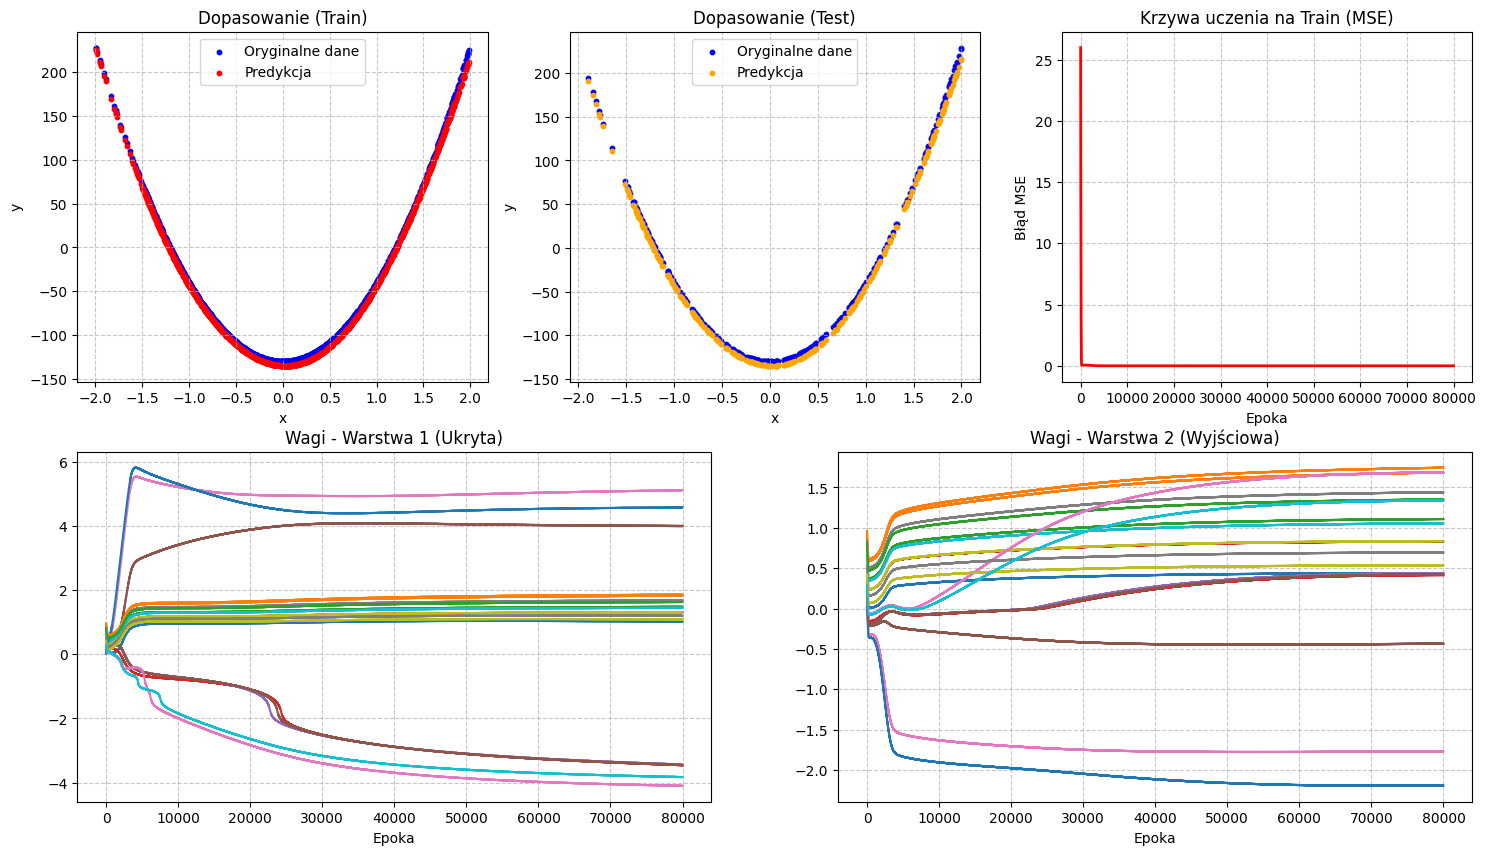

np.float64(27.428364081474857)

In [13]:
lab3_rmsprop(train_path='../../datasets/regression/my-square-large-training.csv',
     test_path='../../datasets/regression/my-square-large-test.csv',
     hidden_layers_sizes = [20],
     epochs = 80000,
     learning_rate = 0.002,
     batch_size = None,
     decay_rate = 0.9
     )

MSE na nieznormalizowanym zbiorze treningowym : 11.1035
MSE na nieznormalizowanym zbiorze testowym    : 220.2927


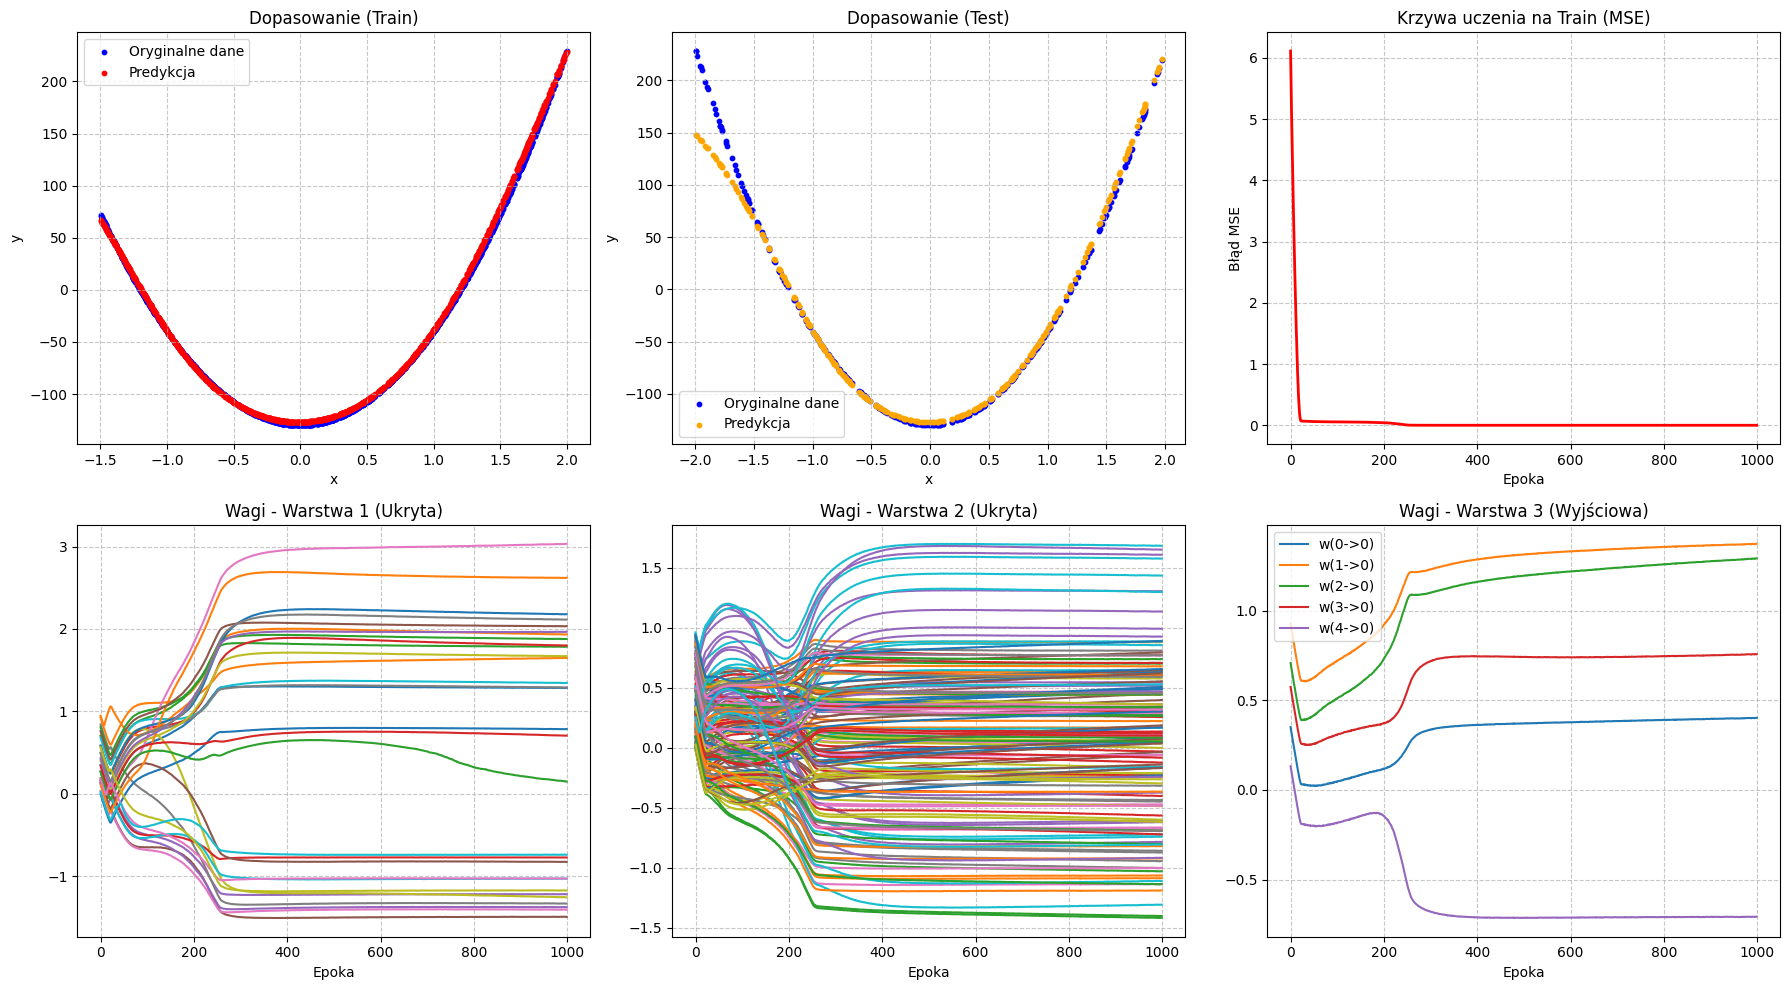

np.float64(220.2927332418379)

In [51]:
lab3_rmsprop(train_path='../../datasets/regression/square-large-training.csv',
     test_path='../../datasets/regression/square-large-test.csv',
     hidden_layers_sizes = [30,5],
     epochs = 1000,
     learning_rate = 0.001,
     batch_size = 64,
     decay_rate = 0.9
     )

MSE na nieznormalizowanym zbiorze treningowym : 29.1159
MSE na nieznormalizowanym zbiorze testowym    : 16.5817


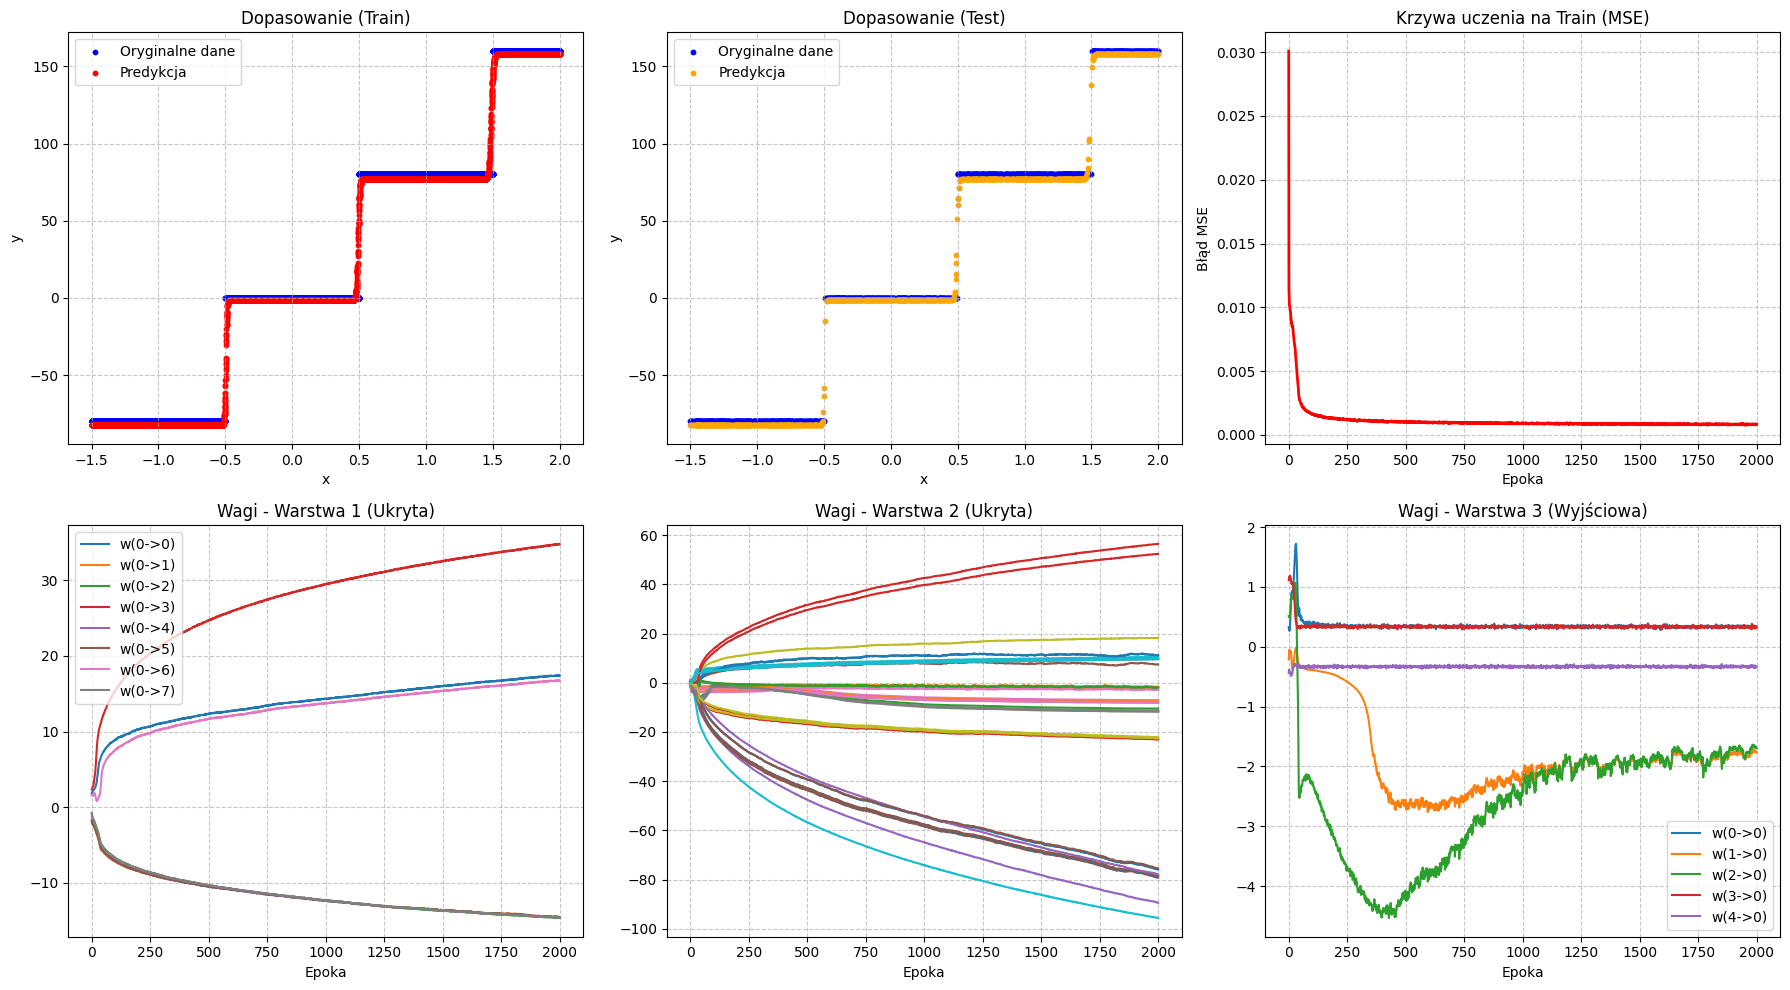

np.float64(16.58166038249859)

In [15]:
lab3_rmsprop(train_path='../../datasets/regression/steps-large-training.csv',
     test_path='../../datasets/regression/steps-large-test.csv',
     hidden_layers_sizes = [8,5],
     epochs = 2000,
     learning_rate = 0.02,
     batch_size = 32,
     init_method = 'xavier',
     decay_rate = 0.9
     )

MSE na nieznormalizowanym zbiorze treningowym : 413.6332
MSE na nieznormalizowanym zbiorze testowym    : 449.2842


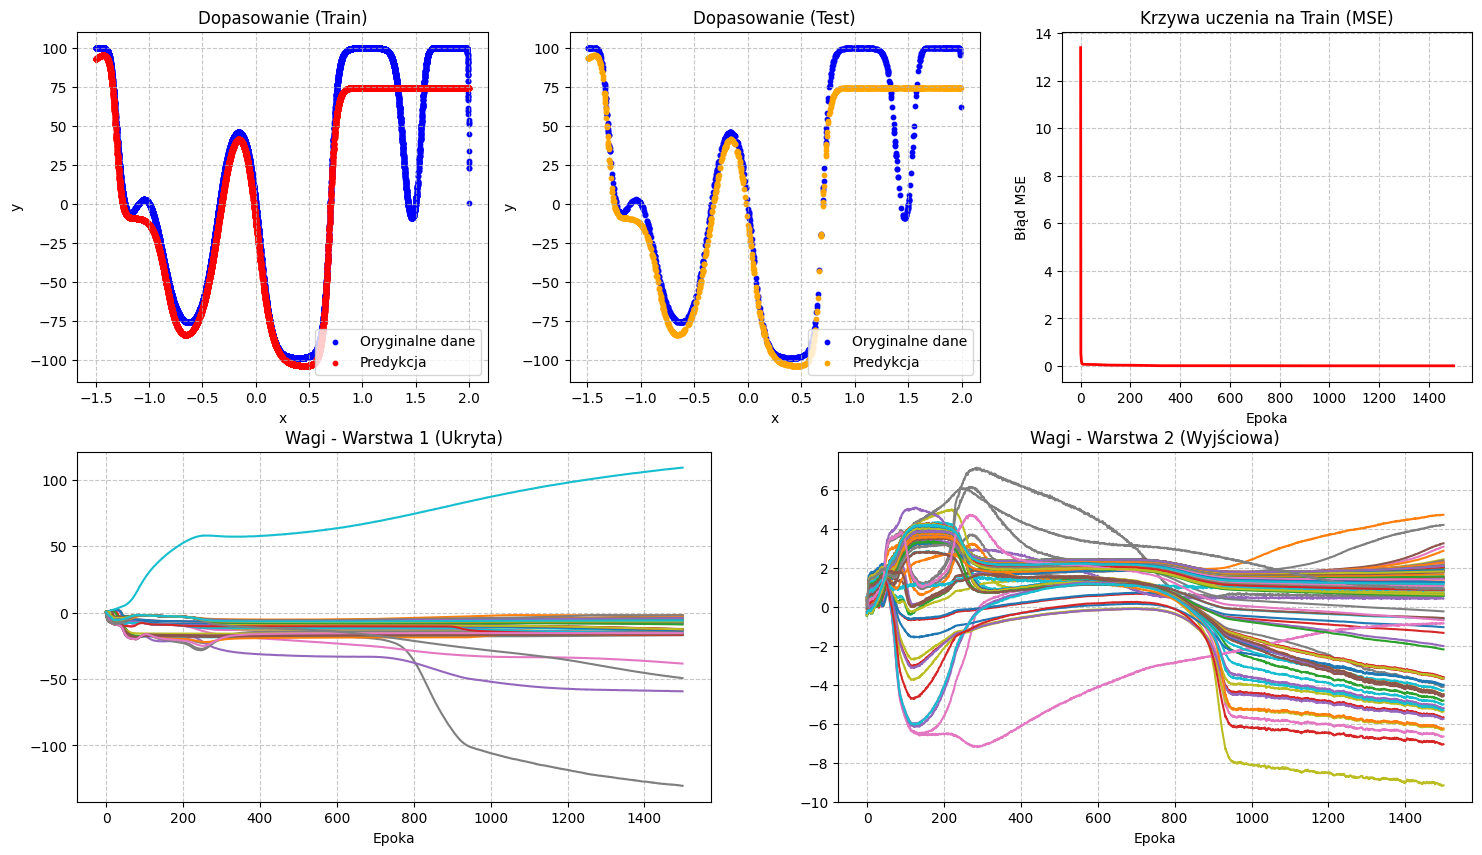

np.float64(449.2841530224086)

In [16]:
lab3_rmsprop(train_path='../../datasets/regression/multimodal-large-training.csv',
     test_path='../../datasets/regression/multimodal-large-test.csv',
     hidden_layers_sizes = [100],
     epochs = 1500,
     learning_rate = 0.03,
     batch_size = 64,
     decay_rate = 0.9
     )